<a href="https://colab.research.google.com/github/wajahat201/Plant-Leaf-Disease-Detection-Using-CNN/blob/main/Plant_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Wajahat Bine Saif

Reg No: 22055

Program: CS

Subject: Artificial Intelligence(AI)



In [7]:
!pip install kaggle

In [8]:
import os

os.environ['KAGGLE_USERNAME'] = "wajahatsaif"
os.environ['KAGGLE_KEY'] = "KGAT_0917f98efd9572455528fa285c0a89db"

print("Kaggle API credentials set successfully!")

Kaggle API credentials set successfully!


In [9]:
!kaggle datasets download -d emmarex/plantdisease


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 97% 639M/658M [00:01<00:00, 300MB/s]
100% 658M/658M [00:01<00:00, 357MB/s]


In [10]:
import zipfile

with zipfile.ZipFile("plantdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [11]:
import os
os.listdir("dataset")

['plantvillage', 'PlantVillage']

In [13]:
os.listdir("dataset/PlantVillage")[:20]

['Tomato_Early_blight',
 'Tomato_Septoria_leaf_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy',
 'Potato___Late_blight',
 'Potato___Early_blight',
 'Tomato_Bacterial_spot',
 'Tomato_Leaf_Mold',
 'Tomato_Late_blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___healthy',
 'Tomato_Spider_mites_Two_spotted_spider_mite']

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("All libraries imported successfully!")

All libraries imported successfully!


In [19]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_dir = "dataset/PlantVillage"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


**Building CNN Model **

In [20]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model **

In [21]:
EPOCHS = 5

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


517/517 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.4672 - loss: 1.6455 - val_accuracy: 0.7955 - val_loss: 0.6035
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - accuracy: 0.8246 - loss: 0.5206 - val_accuracy: 0.8428 - val_loss: 0.4510
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.8902 - loss: 0.3288 - val_accuracy: 0.8816 - val_loss: 0.3678
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step - accuracy: 0.9367 - loss: 0.1906 - val_accuracy: 0.9039 - val_loss: 0.3064
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 527s 1s/step - accuracy: 0.9583 - loss: 0.1286 - val_accuracy: 0.8981 - val_loss: 0.3351


In [22]:
model.save("plant_disease_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [23]:
model.save("plant_disease_model.keras")
print("Model saved successfully in new format!")

Model saved successfully in new format!


In [24]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 286ms/step - accuracy: 0.8859 - loss: 0.3850
Validation Accuracy: 0.8981077075004578


In [25]:
from google.colab import files
uploaded = files.upload()

Saving 5867623319_6f149e16fc_o.jpg to 5867623319_6f149e16fc_o.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


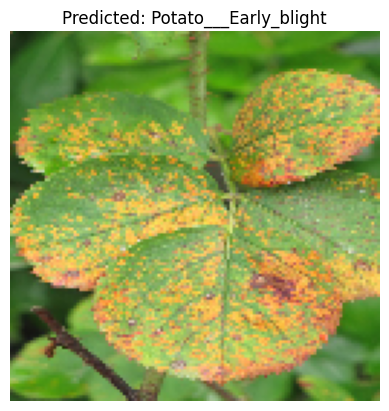

Predicted Disease: Potato___Early_blight


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 128

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get class names
class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

# Show image
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

print("Predicted Disease:", predicted_class)